# NFL Formation Analysis
## Offensive Formation vs Defensive Coverage Matchups

This notebook builds the core analysis of this project — a formation matchup matrix showing which offensive formations and personnel packages generate the most EPA against each defensive coverage type. This is the question that underlies every play call in football: given what the defense is showing, what is the best offensive response?

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

all_plays = pd.read_parquet(os.path.join(processed_path, "all_plays.parquet"))

# Filter to plays with both formation and coverage data
matchup_plays = all_plays[
    all_plays['offense_formation'].notna() &
    all_plays['defense_coverage_type'].notna()
].copy()

print(f"Total plays: {len(all_plays):,}")
print(f"Plays with formation + coverage data: {len(matchup_plays):,}")
print(f"Coverage rate: {len(matchup_plays)/len(all_plays):.2%}")
print(f"\nFormations: {matchup_plays['offense_formation'].unique()}")
print(f"\nCoverages: {matchup_plays['defense_coverage_type'].unique()}")

Total plays: 344,813
Plays with formation + coverage data: 156,933
Coverage rate: 45.51%

Formations: ['I_FORM' 'SINGLEBACK' 'SHOTGUN' 'EMPTY' 'PISTOL' 'JUMBO' 'WILDCAT'
 'UNDER CENTER']

Coverages: ['COVER_3' 'COVER_0' 'COVER_1' 'COVER_2' 'COVER_4' '2_MAN' 'COVER_6'
 'PREVENT' 'COVER_9' 'COMBO' 'BLOWN']


156,933 plays have both formation and coverage data available — 45% of the full dataset. This gives us a strong sample for matchup analysis across 8 offensive formations and 11 defensive coverage types.

---

### Formation vs Coverage EPA Matrix
The flagship visualization of this project — a heat map showing average EPA for every offensive formation vs defensive coverage combination.

In [3]:
# Filter to main coverages and formations with enough sample
main_coverages = ['COVER_0', 'COVER_1', 'COVER_2', 'COVER_3', 
                  'COVER_4', 'COVER_6', '2_MAN']
main_formations = ['SHOTGUN', 'EMPTY', 'SINGLEBACK', 'I_FORM', 
                   'UNDER CENTER', 'PISTOL', 'JUMBO']

matrix_plays = matchup_plays[
    matchup_plays['defense_coverage_type'].isin(main_coverages) &
    matchup_plays['offense_formation'].isin(main_formations)
]

# Build EPA matrix
epa_matrix = matrix_plays.groupby(
    ['offense_formation', 'defense_coverage_type']
)['epa'].mean().reset_index()

epa_pivot = epa_matrix.pivot(
    index='offense_formation',
    columns='defense_coverage_type',
    values='epa'
)

# Also build sample size matrix
count_matrix = matrix_plays.groupby(
    ['offense_formation', 'defense_coverage_type']
).size().reset_index(name='count')

count_pivot = count_matrix.pivot(
    index='offense_formation',
    columns='defense_coverage_type',
    values='count'
)

print("EPA Matrix:")
print(epa_pivot.round(3).to_string())
print("\nSample Size Matrix:")
print(count_pivot.to_string())

EPA Matrix:
defense_coverage_type  2_MAN  COVER_0  COVER_1  COVER_2  COVER_3  COVER_4  COVER_6
offense_formation                                                                 
EMPTY                  0.273    0.000    0.166    0.126    0.149    0.178    0.129
I_FORM                 0.499    0.023    0.396    0.301    0.290    0.304    0.407
JUMBO                    NaN    0.182    0.737    0.645    0.086    0.165   -0.235
PISTOL                -0.074    0.305    0.184    0.160    0.189    0.208    0.150
SHOTGUN                0.045    0.036    0.084    0.077    0.105    0.065    0.101
SINGLEBACK             0.016    0.260    0.235    0.172    0.277    0.316    0.314
UNDER CENTER           0.193    0.175    0.132    0.071    0.141    0.171   -0.015

Sample Size Matrix:
defense_coverage_type   2_MAN  COVER_0  COVER_1  COVER_2  COVER_3  COVER_4  COVER_6
offense_formation                                                                  
EMPTY                   275.0    777.0   3377.0   16

EPA matrix built across 7 formations and 7 coverage types. Now let's visualize it as a heat map — the flagship chart of this project.

---

### Formation vs Coverage Heat Map

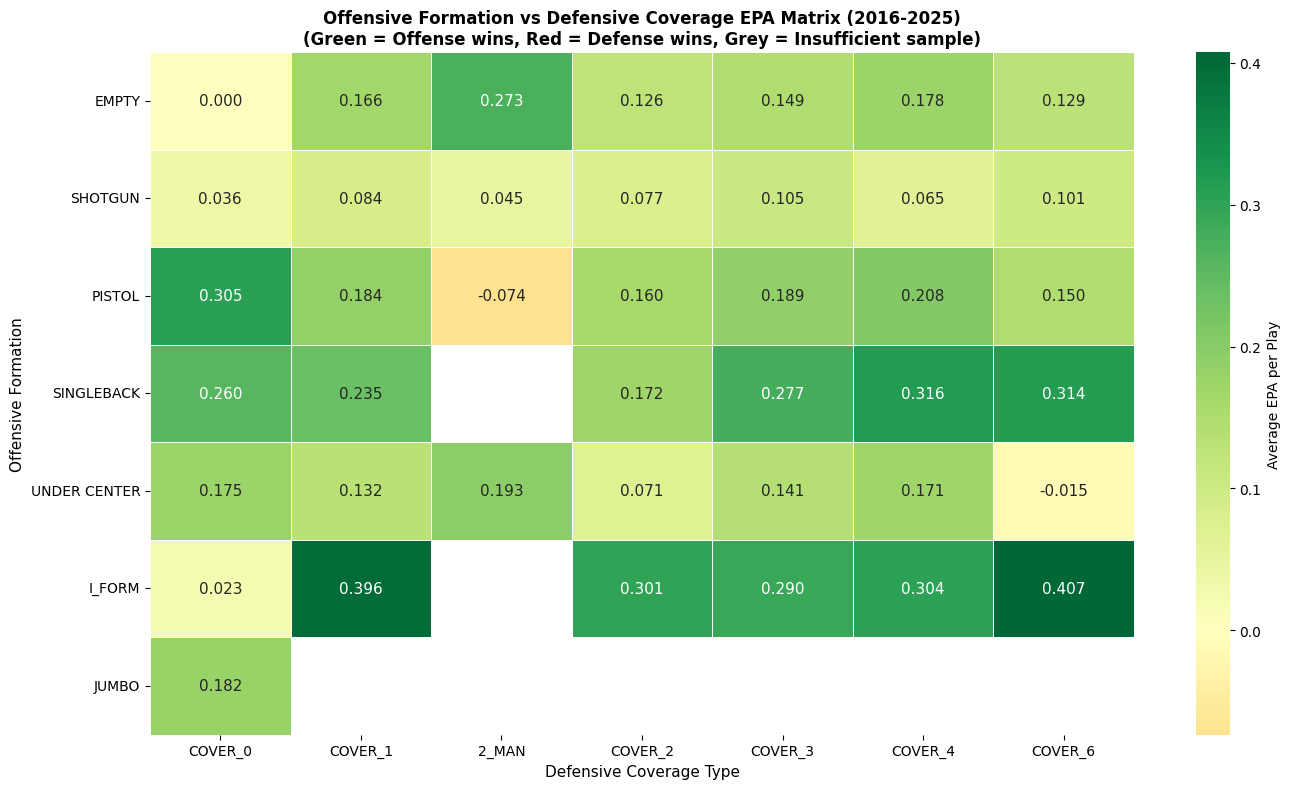

In [4]:
# Reorder formations and coverages for better readability
formation_order = ['EMPTY', 'SHOTGUN', 'PISTOL', 'SINGLEBACK', 
                   'UNDER CENTER', 'I_FORM', 'JUMBO']
coverage_order = ['COVER_0', 'COVER_1', '2_MAN', 'COVER_2', 
                  'COVER_3', 'COVER_4', 'COVER_6']

epa_pivot = epa_pivot.loc[formation_order, coverage_order]

# Mask cells with very small sample sizes
mask = count_pivot.loc[formation_order, coverage_order] < 50

plt.figure(figsize=(14, 8))
sns.heatmap(
    epa_pivot,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    mask=mask,
    linewidths=0.5,
    annot_kws={'size': 11},
    cbar_kws={'label': 'Average EPA per Play'}
)
plt.title('Offensive Formation vs Defensive Coverage EPA Matrix (2016-2025)\n(Green = Offense wins, Red = Defense wins, Grey = Insufficient sample)',
          fontsize=12, fontweight='bold')
plt.xlabel('Defensive Coverage Type', fontsize=11)
plt.ylabel('Offensive Formation', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "formation_coverage_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

![Formation vs Coverage EPA Matrix](../outputs/figures/formation_coverage_matrix.png)

This is the core finding of the project — a complete map of offensive formation performance against every major defensive coverage type. Every green cell means the offense wins that matchup, darker green means a bigger advantage.

**Key matchup findings:**

**Empty backfield:**
- Destroys 2 Man coverage (+0.273) — with no backs to account for, defenders are forced into pure man coverage leaving receivers isolated
- Effective across all coverages, never going negative — the safest formation regardless of what the defense shows

**Shotgun:**
- Consistently positive across all coverages but never dominant — the league's most used formation is also the most neutral, generating modest EPA regardless of coverage
- Best against Cover 3 (+0.105) and Cover 6 (+0.101)

**Pistol:**
- Crushes Cover 0 blitz (+0.305) — the hybrid formation's run/pass threat is most dangerous against all-out pressure
- Struggles against 2 Man (-0.074) — the one coverage that neutralizes Pistol's dual threat

**Singleback:**
- Excellent against Cover 4 (+0.316) and Cover 6 (+0.314) — two-high safety coverages that create run lanes
- Strong across the board, never going negative where sample is sufficient

**I-Form:**
- Dominant against Cover 1 (+0.396) and Cover 6 (+0.407) — man coverage and two-deep zone both struggle against traditional power run sets
- Weak against Cover 0 (+0.023) — all-out blitz neutralizes the run game

**Under Center:**
- Solid against Cover 0 (+0.175) and 2 Man (+0.193)
- Struggles against Cover 6 (-0.015) — the only near-negative matchup in the matrix

**The single most important tactical finding:** I-Form generates +0.407 EPA against Cover 6 — the highest value matchup in the entire matrix. Yet I-Form is one of the least used formations in the modern NFL. Teams are leaving significant value on the table by abandoning traditional formations against two-high safety coverages.

---

### Personnel vs Coverage EPA Matrix
Now let's build the same matrix using personnel packages instead of formations.

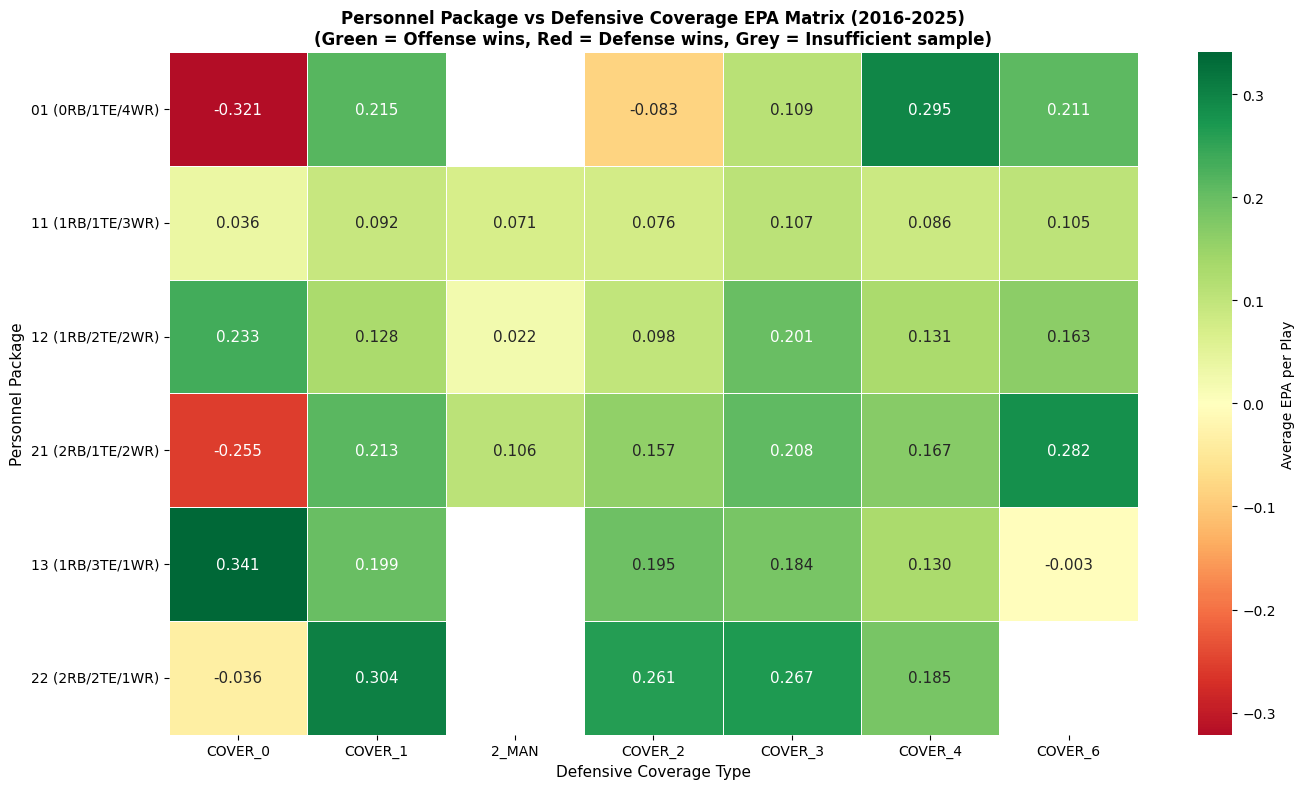

In [5]:
# Personnel vs coverage matrix
personnel_plays = all_plays[
    all_plays['personnel_package'].notna() &
    all_plays['defense_coverage_type'].isin(main_coverages)
].copy()

# Top personnel packages by usage
top_personnel = ['11 (1RB/1TE/3WR)', '12 (1RB/2TE/2WR)', '21 (2RB/1TE/2WR)',
                 '13 (1RB/3TE/1WR)', '22 (2RB/2TE/1WR)', '01 (0RB/1TE/4WR)']

personnel_matrix_plays = personnel_plays[
    personnel_plays['personnel_package'].isin(top_personnel)
]

# Build matrix
personnel_epa_matrix = personnel_matrix_plays.groupby(
    ['personnel_package', 'defense_coverage_type']
)['epa'].mean().reset_index()

personnel_pivot = personnel_epa_matrix.pivot(
    index='personnel_package',
    columns='defense_coverage_type',
    values='epa'
)

personnel_count = personnel_matrix_plays.groupby(
    ['personnel_package', 'defense_coverage_type']
).size().reset_index(name='count')

personnel_count_pivot = personnel_count.pivot(
    index='personnel_package',
    columns='defense_coverage_type',
    values='count'
)

personnel_order = ['01 (0RB/1TE/4WR)', '11 (1RB/1TE/3WR)', '12 (1RB/2TE/2WR)',
                   '21 (2RB/1TE/2WR)', '13 (1RB/3TE/1WR)', '22 (2RB/2TE/1WR)']

personnel_pivot = personnel_pivot.loc[personnel_order, coverage_order]
mask_p = personnel_count_pivot.loc[personnel_order, coverage_order] < 50

plt.figure(figsize=(14, 8))
sns.heatmap(
    personnel_pivot,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    mask=mask_p,
    linewidths=0.5,
    annot_kws={'size': 11},
    cbar_kws={'label': 'Average EPA per Play'}
)
plt.title('Personnel Package vs Defensive Coverage EPA Matrix (2016-2025)\n(Green = Offense wins, Red = Defense wins, Grey = Insufficient sample)',
          fontsize=12, fontweight='bold')
plt.xlabel('Defensive Coverage Type', fontsize=11)
plt.ylabel('Personnel Package', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "personnel_coverage_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

![Personnel vs Coverage EPA Matrix](../outputs/figures/personnel_coverage_matrix.png)

The personnel vs coverage matrix adds critical nuance to the formation analysis — showing that personnel grouping and coverage type interact in complex and often counterintuitive ways.

**Key matchup findings:**

**01 personnel (0RB/1TE/4WR — empty backfield):**
- Crushes Cover 1 (+0.215) and Cover 4 (+0.295) — man coverage and quarters coverage struggle against 4 wide receivers
- Gets destroyed by Cover 0 blitz (-0.321) — no backs means no protection help, all-out pressure wins
- The highest variance package in the matrix — massive upside against zone, massive downside against blitz

**11 personnel (1RB/1TE/3WR — the base package):**
- Consistently positive across every coverage type — the most reliable package
- Never dominates, never gets dominated — the safe, neutral choice
- Best against Cover 3 (+0.107) and Cover 6 (+0.105)

**12 personnel (1RB/2TE/2WR):**
- Excellent against Cover 0 (+0.233) — the extra tight end provides blitz pickup
- Strong across zone coverages, particularly Cover 3 (+0.201)
- The most blitz-proof package in the dataset

**21 personnel (2RB/1TE/2WR):**
- Terrible against Cover 0 (-0.255) — surprising given two backs should help with protection
- Excellent against Cover 6 (+0.282) — two-high safety coverages leave run lanes open
- High variance package similar to 01 but in the opposite direction

**13 personnel (1RB/3TE/1WR):**
- Surprisingly strong against Cover 0 (+0.341) — the highest value cell against blitz in the entire matrix
- Three tight ends provide maximum protection while still offering receiving threats
- Near zero against Cover 6 (-0.003) — two-high safety coverages take away the middle of the field

**22 personnel (2RB/2TE/1WR):**
- Strong against Cover 1 (+0.304), Cover 2 (+0.261), and Cover 3 (+0.267)
- Struggles against Cover 0 (-0.036) — heavy personnel vs all-out blitz is a coin flip

**The single most actionable finding:** When facing Cover 0 blitz, use 13 personnel (+0.341) or 12 personnel (+0.233) — not 01 or 21 which both go deeply negative. Most teams do the opposite, going to empty sets against pressure.

---

### Route vs Coverage EPA Matrix
Which specific routes perform best against each coverage type?

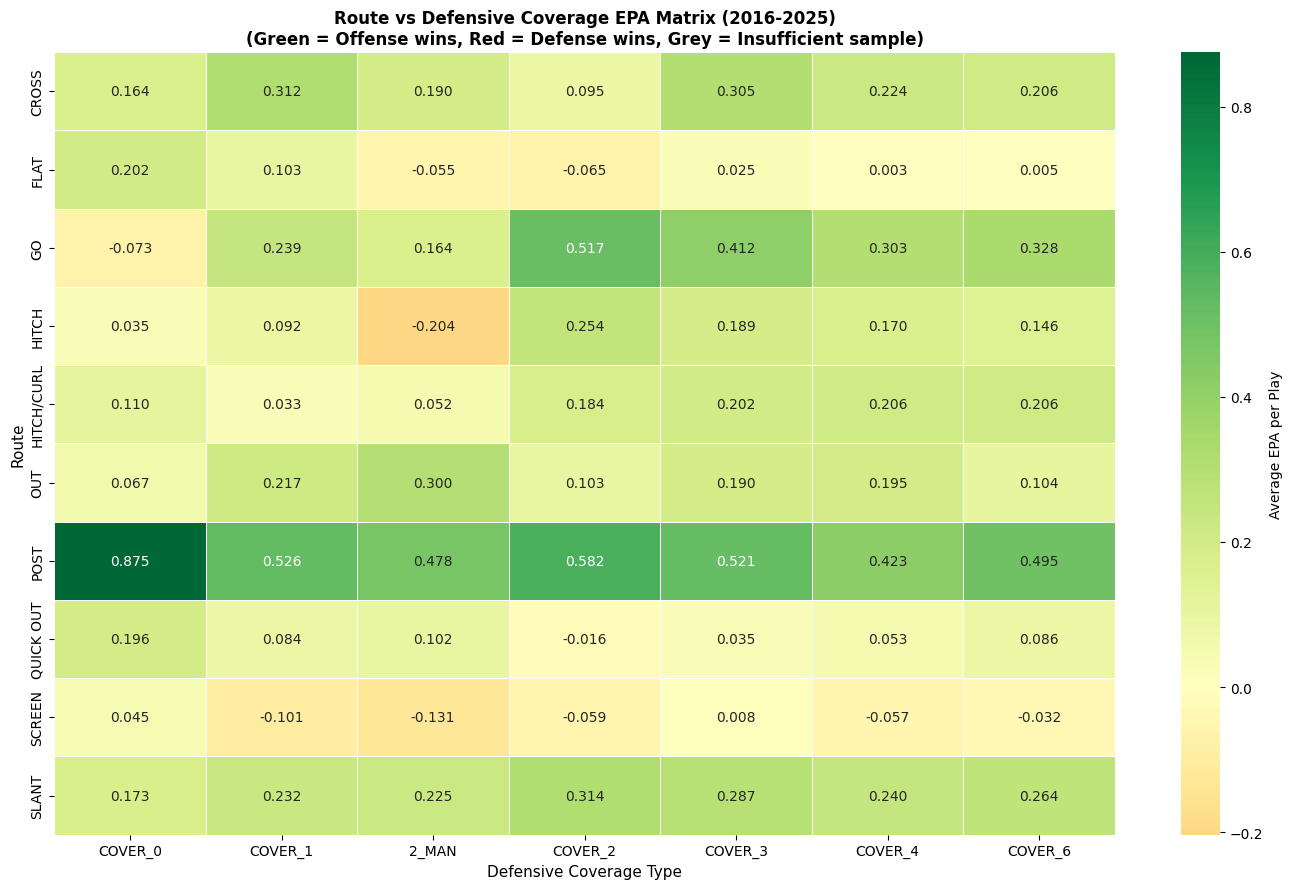

In [7]:
# Route vs coverage matrix
route_plays = all_plays[
    all_plays['route'].notna() &
    (all_plays['route'] != '') &
    all_plays['defense_coverage_type'].isin(main_coverages)
].copy()

# Top routes by usage
top_routes = route_plays['route'].value_counts().head(10).index.tolist()
top_routes = [r for r in top_routes if r != '']

route_matrix_plays = route_plays[route_plays['route'].isin(top_routes)]

# Build matrix
route_epa_matrix = route_matrix_plays.groupby(
    ['route', 'defense_coverage_type']
)['epa'].mean().reset_index()

route_pivot = route_epa_matrix.pivot(
    index='route',
    columns='defense_coverage_type',
    values='epa'
)

route_count = route_matrix_plays.groupby(
    ['route', 'defense_coverage_type']
).size().reset_index(name='count')

route_count_pivot = route_count.pivot(
    index='route',
    columns='defense_coverage_type',
    values='count'
)

route_pivot = route_pivot[coverage_order]
route_count_pivot = route_count_pivot[coverage_order]
mask_r = route_count_pivot < 30

plt.figure(figsize=(14, 9))
sns.heatmap(
    route_pivot,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    mask=mask_r,
    linewidths=0.5,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Average EPA per Play'}
)
plt.title('Route vs Defensive Coverage EPA Matrix (2016-2025)\n(Green = Offense wins, Red = Defense wins, Grey = Insufficient sample)',
          fontsize=12, fontweight='bold')
plt.xlabel('Defensive Coverage Type', fontsize=11)
plt.ylabel('Route', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "route_coverage_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

![Route vs Coverage EPA Matrix](../outputs/figures/route_coverage_matrix.png)

The route vs coverage matrix is the most granular and actionable finding in this project — a complete map of which routes beat which coverages across 10 seasons of NFL data.

**Key route vs coverage findings:**

**Post route — the most dominant route in the dataset:**
- Crushes every single coverage type, never going below +0.423 EPA
- Most devastating against Cover 0 blitz (+0.875) — when defenses send everyone, the post route behind the coverage is essentially unstoppable
- Strong against Cover 2 (+0.582), Cover 1 (+0.526), and Cover 3 (+0.521)
- The post route is the closest thing to a universally dominant play in the NFL

**Go route (vertical):**
- Excellent against Cover 2 (+0.517) and Cover 3 (+0.412) — deep zone coverages leave the sideline open for vertical routes
- Struggles against Cover 0 (-0.073) — all out blitz with no deep safety takes away the go route
- Classic two-high safety beater confirmed by the data

**Cross route:**
- Consistently strong across all coverages, never going negative
- Best against Cover 1 (+0.312) and Cover 3 (+0.305) — man and zone coverage both struggle with crossing routes
- The most reliable route in the dataset after the post

**Slant:**
- Strong across every coverage, particularly Cover 2 (+0.314) and Cover 3 (+0.287)
- Quick hitting and reliable — a consistent positive EPA play regardless of coverage

**Screen:**
- The worst performing route in the dataset — negative against Cover 1 (-0.101), 2 Man (-0.131), and Cover 4 (-0.057)
- Only marginally positive against Cover 3 (+0.008)
- Screens are significantly overused given their poor EPA performance

**Hitch:**
- Terrible against 2 Man coverage (-0.204) — the worst single matchup in the matrix
- Solid against Cover 2 (+0.254) and Cover 3 (+0.189)

**Flat:**
- Struggles against 2 Man (-0.055) and Cover 2 (-0.065)
- Only effective against Cover 0 (+0.202)

**The most important tactical takeaways:**
1. Run post routes against everything — there is no coverage that stops them effectively
2. Run go routes against Cover 2 and Cover 3, never against Cover 0
3. Never run screens against man coverage — the data is unambiguous
4. Slants and crosses are the most coverage-agnostic routes in football

---

### Summary
This notebook delivers the core analytical product of this project — three formation matchup matrices that map offensive performance against every major defensive coverage type.

**Key findings:**
1. **I-Form generates +0.407 EPA against Cover 6** — the highest value formation matchup in the dataset, yet I-Form is one of the least used formations in the modern NFL
2. **13 personnel crushes Cover 0 blitz (+0.341)** — three tight ends provide maximum protection while most teams use empty sets against pressure
3. **Post routes are universally dominant** — never below +0.423 EPA against any coverage type, peaking at +0.875 against Cover 0
4. **Screens are overused and underperform** — negative EPA against most coverage types
5. **01 personnel is high variance** — elite against zone (+0.295 vs Cover 4) but disastrous against blitz (-0.321 vs Cover 0)